<a href="https://colab.research.google.com/github/nguyenhuuphan/Colab/blob/main/machine_learning/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MACHINE LEANRING BASICS

##  KNN

(np.float64(0.8), np.float64(5.2), np.float64(0.8), np.float64(5.2))

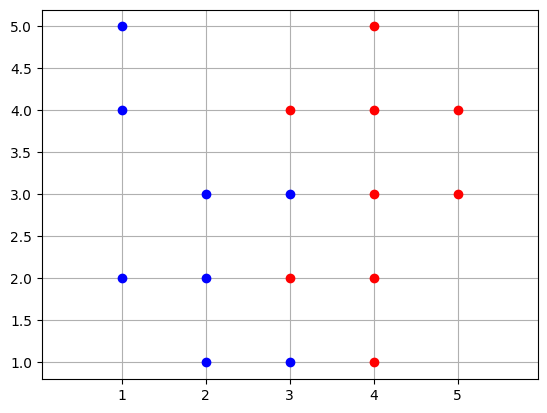

In [ ]:
# KNN
import numpy as np
import matplotlib.pyplot as plt
X = [[1,2],
     [1,4],
     [1,5],
     [2,1],
     [2,2],
     [2,3],
     [3,1],
     [3,3],
     [3,2],
     [3,4],
     [4,1],
     [4,2],
     [4,3],
     [4,4],
     [4,5],
     [5,3],
     [5,4]]
X = np.array(X)
y = np.array([0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1])

plt.figure()
plt.plot(X[y==0,0], X[y==0,1], 'bo')
plt.plot(X[y==1,0], X[y==1,1], 'ro')
plt.grid('on')
plt.axis('equal')

## Perceptron - Multi label
*   Perceptron nguyên thủy
*   Perceptron nâng cấp
*   Giải thuật huấn luyện:
1/ Khởi tạo k bộ wj thuoojc R^d+1
2/ Lặp:
Lần lượt kiểm tra từng điểm dữ liệu:
[x/1]^T x wi xem wi có thỏa đk nhãn chưa.
x có nhãn c, nhưng yj max.







In [ ]:
import numpy as np

X = np.array([[-1, -1, 1], [-2, 0, 1], [0, 1, 1], [2, 1, 1]]) # thêm số 1, tăng chiều d -> d+1
y = np.array([0,1,2,2])
W = np.array([[0,-1,0], [1,1,0], [0,1,0]])

count = 0
while (count != 4):
  for x in X:
    out = W @ x
    max_index = 0
    for i in range(len(out)):
      if out[i] == max(out):
        max_index = i
        if max_index == y[i]:
          count += 1
          break
        if max_index != y[i]:
          W[y[i]] = W[y[i]] + x
          W[max_index] = W[max_index] - x
          count = 0
    print(x)
    print(W)
    print(out)



[-1 -1  1]
[[ 0 -1  0]
 [ 1  1  0]
 [ 0  1  0]]
[ 1 -2 -1]
[-2  0  1]
[[ 0 -1  0]
 [ 1  1  0]
 [ 0  1  0]]
[ 0 -2  0]
[0 1 1]
[[ 0 -1  0]
 [ 1  1  0]
 [ 0  1  0]]
[-1  1  1]
[2 1 1]
[[ 0 -1  0]
 [ 1  1  0]
 [ 0  1  0]]
[-1  3  1]


[[-1 -1  1]
 [-2  0  1]
 [ 0  1  1]
 [ 2  1  1]]
[[ 0 -1  0]
 [ 1  1  0]
 [ 0  1  0]]
========== Huan luyen ===============
x [-1 -1  1] L 0
out [ 1 -2 -1]
Dung
x [-2  0  1] L 1
out [ 0 -2  0]
Sai
W [[ 2 -1 -1]
 [-1  1  1]
 [ 2  1 -1]]
x [0 1 1] L 2
out [-2  2  0]
Sai
W [[ 2 -1 -1]
 [-1  0  0]
 [ 2  2  0]]
x [2 1 1] L 2
out [ 2 -2  6]
Dung
x [-1 -1  1] L 0
out [-2  1 -4]
Sai
W [[ 1 -2  0]
 [ 0  1 -1]
 [ 2  2  0]]
x [-2  0  1] L 1
out [-2 -1 -4]
Dung
x [0 1 1] L 2
out [-2  0  2]
Dung
x [2 1 1] L 2
out [0 0 6]
Dung
x [-1 -1  1] L 0
out [ 1 -2 -4]
Dung
Ket qua huan luyen:
 [[ 1 -2  0]
 [ 0  1 -1]
 [ 2  2  0]]


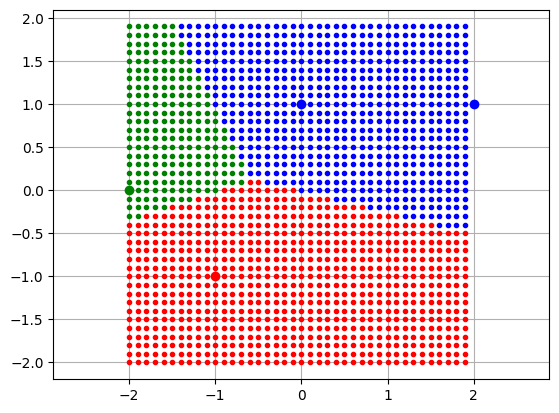

In [1]:
import numpy as np

X = np.array([[-1,-1,1],[-2,0,1],[0,1,1],[2,1,1]]) # them so 1, tang chieu d --> d+1
y = np.array([0,1,2,2])
print(X)

W = np.array([[0,-1,0],[1,1,0],[0,1,0]])
print(W)
count = 0

print("========== Huan luyen ===============")
while (True):
    for x, c in zip(X, y):
        print('x',x,'L',c)
        out = W @ x
        print('out', out)
        if out[c] != max(out):
            print('Sai')
            W[c] = W[c] + x
            count = 0
            for j in np.arange(len(W)):
                if out[j] == max(out) and j!=c:
                    W[j] = W[j] - x
            print('W', W)
        else:
            print('Dung')
            count = count + 1
            if count == 4:
                break

    if count == 4:
        break
print('Ket qua huan luyen:\n', W)

import matplotlib.pyplot as plt
plt.figure()
color = 'rgb'
for xx,i in zip(X,np.arange(len(y))):
    plt.plot(xx[0],xx[1], color[y[i]]+'o')
plt.grid('on')
plt.axis('equal')

for x1 in np.arange(-2,2,0.1):
    for x2 in np.arange(-2,2,0.1):
        xx = np.array([x1,x2,1])
        out = W @ xx
        id = np.argmax(out)
        plt.plot(xx[0],xx[1], color[id]+'.')

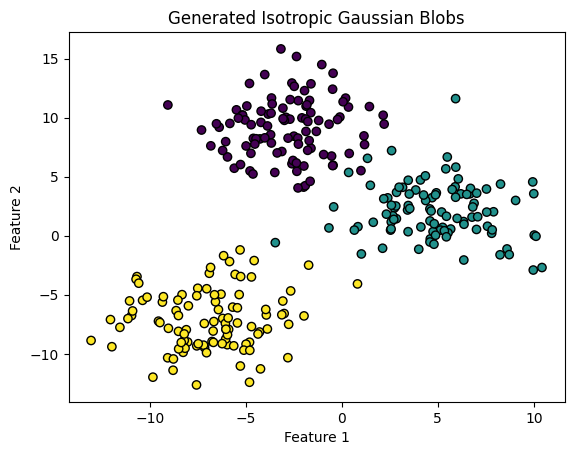

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 2D synthetic blob data
X, y = make_blobs(
    n_samples=300,  # Total number of points
    centers=3,  # Number of clusters (blobs)
    n_features=2,  # Number of dimensions/features per point
    cluster_std=2.5,  # Standard deviation (spread) of the clusters
    random_state=42,  # Seed for reproducibility
)

# Plot the generated data points
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolors="k")
plt.title("Generated Isotropic Gaussian Blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

X = np.hstack((X, np.ones((len(X),1))))

In [7]:
import plotly.graph_objects as go

temp  = np.arange(-10,10,0.5)
X, Y = np.meshgrid(temp, temp)

Z = np.zeros((5,len(temp),len(temp)))

for i in np.arange(0,len(W)):
    wi = W[i]
    Z[i] = wi[0]*X + wi[1]*Y + wi[2]

    # Create a new Plotly figure
fig = go.Figure(
    data=[
        go.Surface( x=X, y=Y, z=Z[0], colorscale='dense', opacity=1, name=' 1'        ),
        go.Surface( x=X, y=Y, z=Z[1], colorscale='armyrose', opacity=1, name=' 2'        ),
        go.Surface( x=X, y=Y, z=Z[2], colorscale='peach', opacity=1, name=' 3'        ),
        go.Surface( x=X, y=Y, z=Z[3], colorscale='hot', opacity=1, name=' 4'        ),
        go.Surface( x=X, y=Y, z=Z[4], colorscale='mint', opacity=1, name=' 5'        )
    ]
)
fig.show()

Chuyển từ Perceptron mặt phẳng tuyến tính sang đường/mặt cong phân chia phi tuyến.
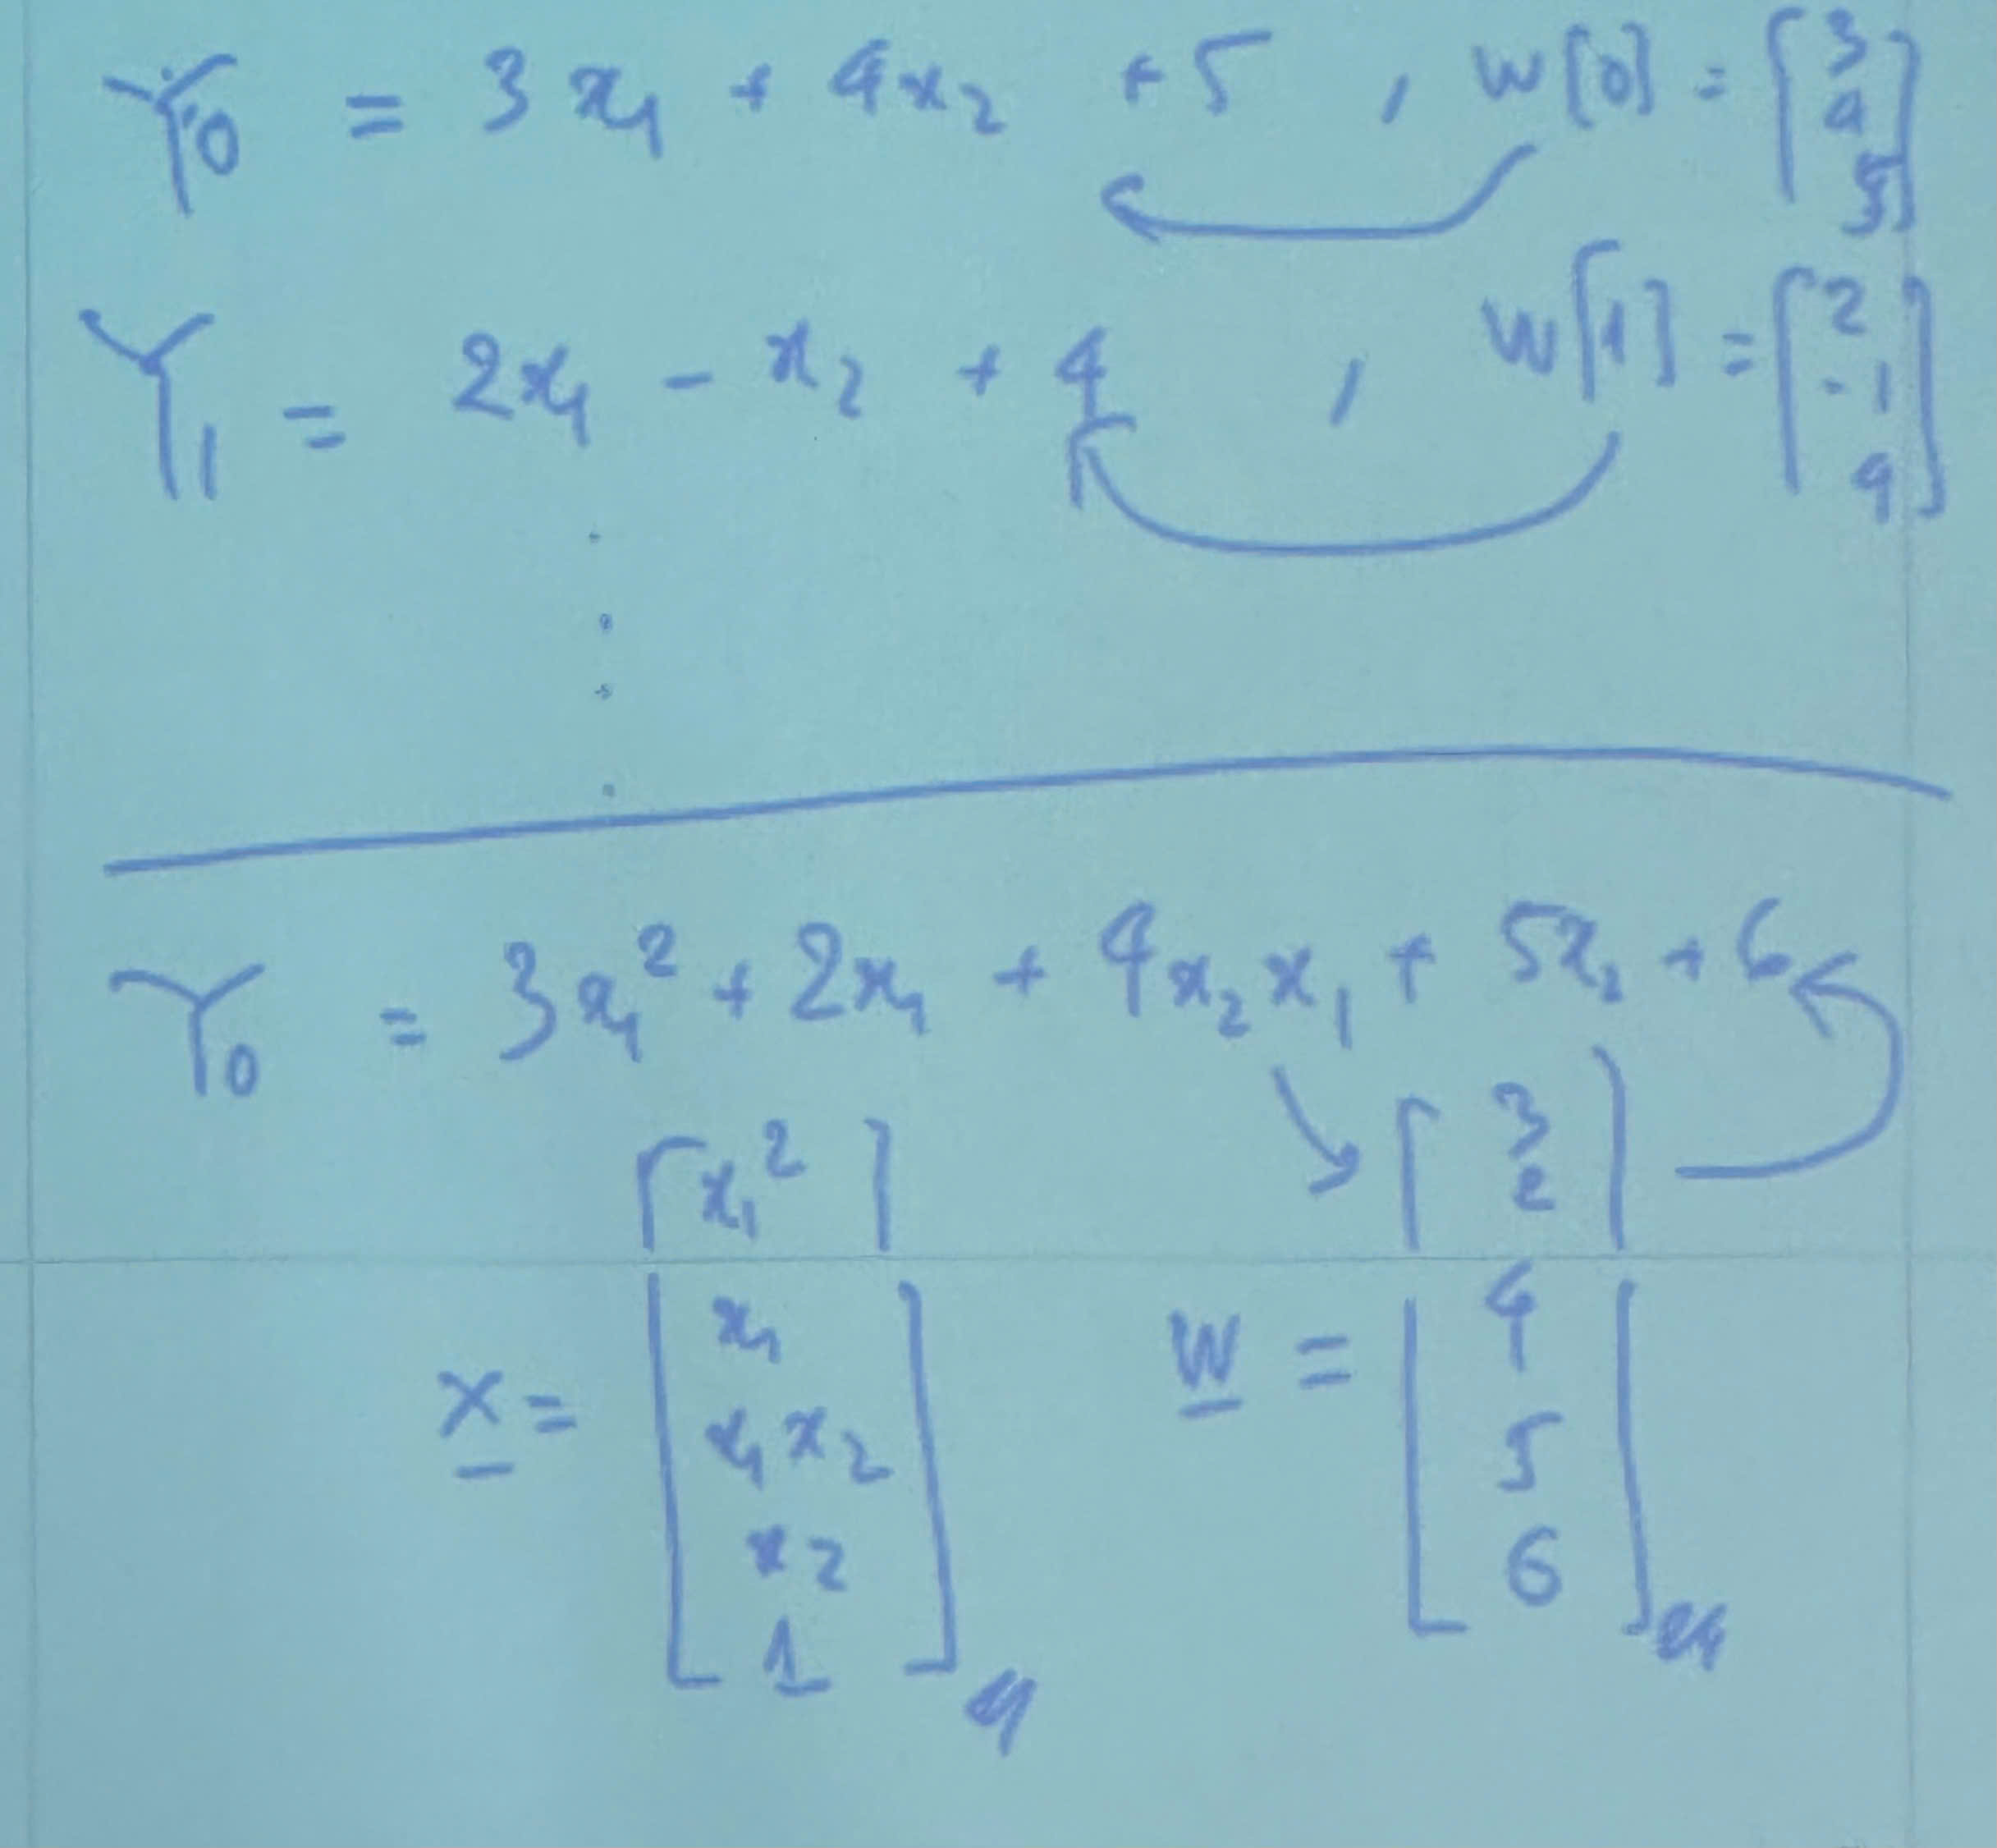

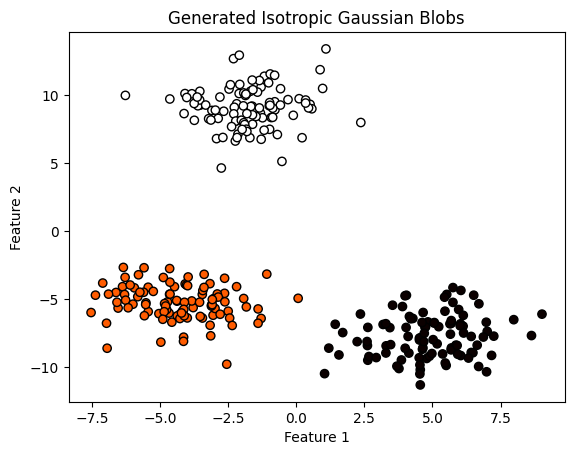

========== Huan luyen ===============
Ket qua huan luyen:
 [[ 2.36194635e+01 -2.56937655e+01 -4.27628995e+00 -2.20422934e+00
  -3.82817590e+00]
 [-3.36128961e+00 -2.92983576e+01  3.36902914e+00  7.63169730e+00
   1.83106129e-01]
 [-1.90996524e+01  5.70439560e+01  2.96494701e-02 -6.87873265e+00
   3.42040534e+00]]


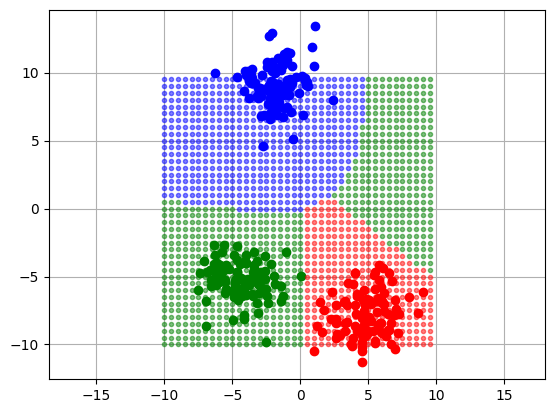

In [15]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 2D synthetic blob data
X, y = make_blobs(
    n_samples=300,  # Total number of points
    centers=3,  # Number of clusters (blobs)
    n_features=2,  # Number of dimensions/features per point
    cluster_std=1.5,  # Standard deviation (spread) of the clusters
    # random_state=42,  # Seed for reproducibility
)

# Plot the generated data points
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="hot", edgecolors="k")
plt.title("Generated Isotropic Gaussian Blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# print(X.shape, np.array([X[:,0]])).T.shape)
x1 = np.array([X[:,0]]).T
x2 = np.array([X[:,1]]).T
X = np.hstack( (X, x1**2, x2*x1, x1*0+1))
W = np.random.randn(3,5)
count = 0
epoch = 0
lr = 0.5
print("========== Huan luyen ===============")
while (True):
    epoch +=1
    for x, c in zip(X, y):
        out = W @ x
        if out[c] != max(out):
            W[c] = W[c] + lr*x
            count = 0
            for j in np.arange(len(W)):
                if out[j] == max(out) and j!=c:
                    W[j] = W[j] - lr*x
        else:
            count = count + 1
            if count == 300:
                break

    if count == 300 or epoch==50:
        break
print('Ket qua huan luyen:\n', W)

import matplotlib.pyplot as plt
plt.figure()
color = 'rgb'
for xx,i in zip(X,np.arange(len(y))):
    plt.plot(xx[0],xx[1], color[y[i]]+'o')
plt.grid('on')
plt.axis('equal')

for x1 in np.arange(-10,10,0.5):
    for x2 in np.arange(-10,10,0.5):
        xx = np.array([x1,x2,x1**2,x1*x2,1])
        out = W @ xx
        id = np.argmax(out)
        plt.plot(xx[0],xx[1], color[id]+'.', alpha=0.5)


import plotly.graph_objects as go

temp  = np.arange(-10,10,0.5)
X, Y = np.meshgrid(temp, temp)

Z = np.zeros((3,len(temp),len(temp)))

for i in np.arange(0,len(W)):
    wi = W[i]
    Z[i] = wi[0]*X + wi[1]*Y + wi[2]*X**2 + wi[3]*X*Y + wi[4]

    # Create a new Plotly figure
fig = go.Figure(
    data=[
        go.Surface( x=X, y=Y, z=Z[0], colorscale='purples', opacity=1, name=' 1'        ),
        go.Surface( x=X, y=Y, z=Z[1], colorscale='hot', opacity=1, name=' 1'        ),
        go.Surface( x=X, y=Y, z=Z[2], colorscale='viridis', opacity=1, name=' 1'        ),

    ]
)
fig.show()